In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from ctw.tree import Tree, view_tree, TreeNode, __visualize_tree
from ctw.models import Quantizer
from ctw.series import AR
from matplotlib import pyplot as plt

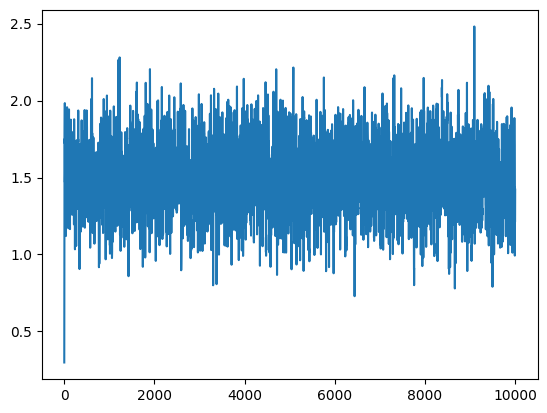

In [3]:
ar_model =AR(p = 2, coeffs= [1.2, -0.4], sigma = 0.1, n_sample=10000, constant_term = 0.3)
x = [data for data in ar_model]
plt.plot(x)


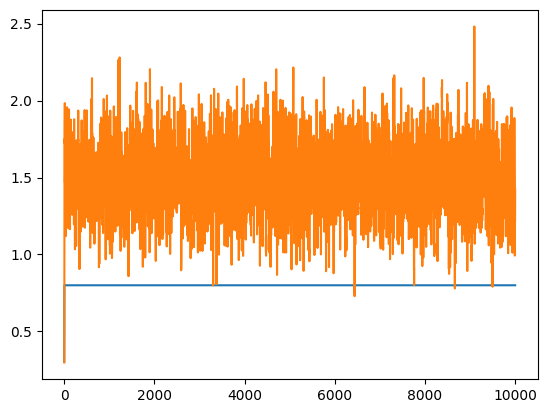

In [4]:
import numpy as np
thresholds = np.linspace(-0.8, 0.8, 30)
quantizer = Quantizer(thresholds=thresholds)

quantized_x = [quantizer.quantize(xi) for xi in x]

unquantized_x = [quantizer.unquantize(qi) for qi in quantized_x]
plt.plot(unquantized_x)
plt.plot(x)


In [5]:
from ctw.models import LiveARTree
live_ar_tree = LiveARTree(max_depth=2, order=2, quantizer=quantizer, tau=10000, lambda_=100, constant_term=True)
y = x[::]
for x_i in y:
    live_ar_tree.observe(x_i)

# ar_tree = ARTree(max_depth=2, order=2, quantizer=quantizer)
# ar_tree.build_from_string(y)
# ar_tree.compute_ctw(y)
# ar_tree.compute_bct(y)
# ar_tree.compute_map_parameters()

# view_tree(ar_tree.tree)

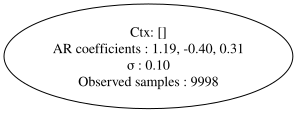

In [6]:
view_tree(live_ar_tree.tree)
# print(live_ar_tree.tree.root.data)

In [7]:
predictions = []
actuals = []

for i in range(2, len(x)):
    hist = x[i-2:i]
    pred = live_ar_tree.predict(hist)
    predictions.append(pred)
    actuals.append(x[i])

# print(live_ar_tree.predict([0, -1]))

## Compute rmse between predictions and actuals
predictions = np.array(predictions)
actuals = np.array(actuals)
rmse = np.sqrt(np.mean((predictions - actuals) ** 2))
print(f"RMSE: {rmse}")

True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3
True 3

In [8]:
from ctw.tree import Tree, TreeNode, view_tree
import numpy as np
from matplotlib import pyplot as plt
from ctw.models import Quantizer

def generate(init_seq = [0.0, 0.0], n_samples=1000) :
    x = init_seq[:]
    pos_ar_coeff = [0.5, -0.3]
    pos_var = 0.1
    neg_ar_coeff = [-0.4, 0.2]
    neg_var = 0.2
    for i in range(n_samples) :
        if x[-2] > 0 :
            x.append(pos_ar_coeff[0]*x[-1] + pos_ar_coeff[1]*x[-2] + np.random.normal(0, pos_var))
        else :
            x.append(neg_ar_coeff[0]*x[-1] + neg_ar_coeff[1]*x[-2] + np.random.normal(0, neg_var))
    return x

x = generate(n_samples=10000)
# print(x)
# plt.plot(x)

from ctw.models import LiveARTree
from ctw.models import Quantizer
# thresholds = np.linspace(-1.0, 1.0, 10)
thresholds = [-0.5, 0.0, 0.5, 1.0]
quantizer = Quantizer(thresholds=thresholds)
live_ar_tree = LiveARTree(max_depth=2, order=2, quantizer=quantizer, beta = 0.5, tau=1.0, lambda_=1.0)
for x_i in x :
    live_ar_tree.observe(x_i)
print(live_ar_tree.tree.root.data)


# ARTree_model = ARTree(max_depth=2, order=2, quantizer=quantizer, beta = 0.5)
# ARTree_model.build_from_string(x)
# ARTree_model.compute_ctw(x)

# view_tree(live_ar_tree.tree)
# 

{'context': [], 'log_P_w,s': array([[4238.61489367]]), 'log_P_m,s': array([[4238.551738]]), 'BS_len': 10000, 's1': 378.1353291133764, 's2': array([[ -0.42346012],
       [-33.74468708]]), 'S3': array([[378.13389328,  -0.42662835],
       [ -0.42662835, 378.12690246]]), 'log_Pe': array([[2193.35004022]]), 'ms': array([[-0.00121707],
       [-0.08900768]]), 'var': array([[0.03769805]]), 'sum_log_P_w,s_children': array([[4239.30804085]]), 'sum_log_P_m,s_children': array([[4239.24488518]]), 'leaf_ctw': False, 'leaf_cbct': False, 'D_s': array([[375.13127739]])}


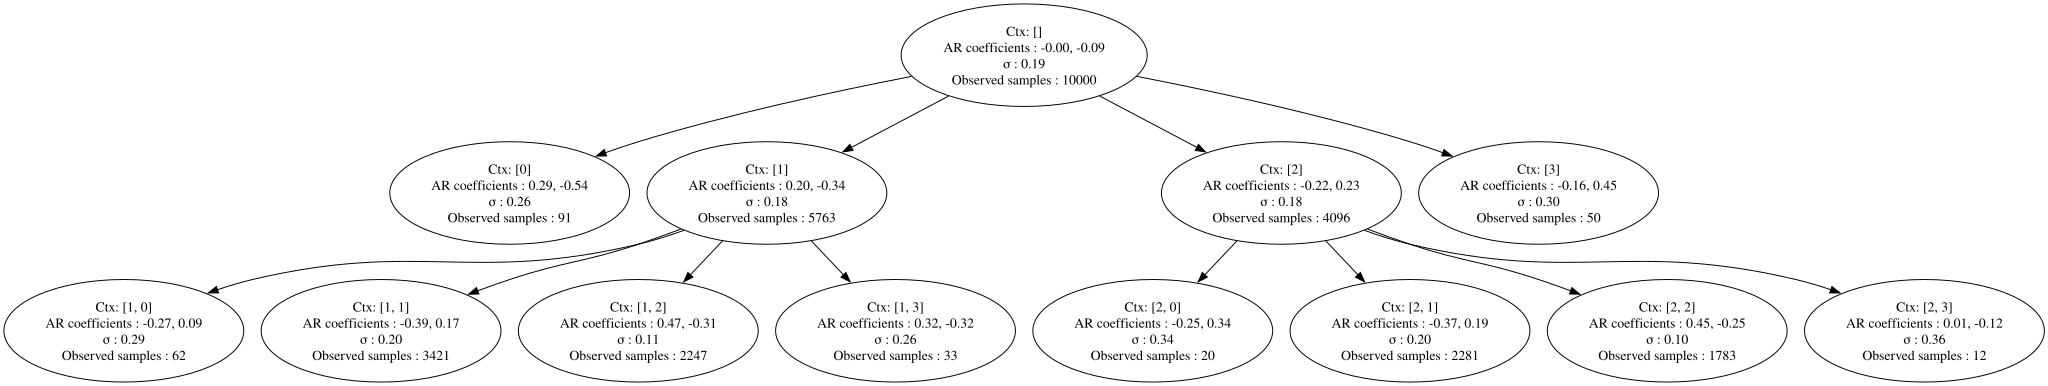

In [9]:
view_tree(live_ar_tree.tree)